In [1]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import sqlite3
import pandas as pd
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve, roc_curve, auc

### Data Preprocessing

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load the training data
df = pd.read_csv('/content/drive/MyDrive/viral-db.csv')
print("Training Data Head:")
display(df.head())

Training Data Head:


,topic_id,forum_id,alpha,beta,min_post_content_length,min_user_post_count,min_user_thread_count,sigma_sus,sigma_fos,delta_t,...,tf8,tf9,tf10,tf11,tf12,tf13,tf14,tf15,tf16,class_label
0,7221,4,20,100,10,5,2,30,14,213.53,...,19,3.334154,0.339339,1.172888,0.037204,30,5,0.712929,5,1
1,7252,4,20,100,10,5,2,30,14,524.96,...,6,39.835165,0.516667,11.049710,0.036159,20,5,0.725624,5,1
2,7293,4,20,100,10,5,2,30,14,204.59,...,8,34.089689,0.467836,12.027684,0.072748,13,5,0.504155,5,1
3,7609,4,20,100,10,5,2,30,14,493.87,...,5,4.601480,0.484190,2.795248,0.112258,22,4,0.714556,4,1
4,7182,4,20,100,10,10,5,30,14,-1.00,...,7,7.142857,0.222222,3.168949,0.030322,3,4,0.691358,4,0


In [4]:
# Data preprocessing

# Group-based split by topic_id
unique_topics = df['topic_id'].unique()
train_topics, val_test_topics = train_test_split(
    unique_topics, test_size=0.4, random_state=42
)
val_topics, test_topics = train_test_split(
    val_test_topics, test_size=0.5, random_state=42
)

train_df = df[df['topic_id'].isin(train_topics)]
val_df   = df[df['topic_id'].isin(val_topics)]
test_df  = df[df['topic_id'].isin(test_topics)]

# Feature selection (rf + ef)
feature_cols = [col for col in df.columns if col.startswith('rf') or col.startswith('ef') and col != 'class_label']

X_train = train_df[feature_cols]
y_train = train_df['class_label']
X_val = val_df[feature_cols]
y_val = val_df['class_label']
X_test = test_df[feature_cols]
y_test = test_df['class_label']

# Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)
y_train = y_train.values
y_val   = y_val.values
y_test  = y_test.values

# Shuffle
X_train, y_train = shuffle(X_train, y_train, random_state=42)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (43269, 25)
X_val: (15240, 25)
X_test: (13735, 25)


### Model Evaluation

In [5]:
def evaluate_model(y, y_pred):
  classes = np.unique(y)
  precisions, recalls, f1_scores, class_size = [], [], [], []

  class_to_idx = {}
  for i, c in enumerate(classes):
      class_to_idx[c] = i

  confusion_matrix = np.zeros((len(classes), len(classes)), dtype=int)
  for i in range(len(y)):
    true_c = y[i]
    pred_c = y_pred[i]

    true_idx = class_to_idx[true_c]
    pred_idx = class_to_idx[pred_c]

    confusion_matrix[true_idx][pred_idx] += 1

  for c in classes:
    TP = np.sum((y == c) & (y_pred == c))
    FP = np.sum((y != c) & (y_pred == c))
    FN = np.sum((y == c) & (y_pred != c))
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * TP / (2 * TP + FP + FN) if (2 * TP + FP + FN) > 0 else 0
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)
    class_size.append(np.sum(y == c))

  mse = np.mean((y - y_pred) ** 2)
  f1_scores = np.array(f1_scores)
  class_size = np.array(class_size)
  weighted_f1_score = np.sum(f1_scores * class_size) / np.sum(class_size)

  metrics = {
      'accuracy': np.mean(y == y_pred),
      'precision': np.mean(precisions),
      'recall': np.mean(recalls),
      'macro_f1_score': np.mean(f1_scores),
      'mse': mse,
      'weighted_f1_score': weighted_f1_score,
      'confusion_matrix': confusion_matrix,
      'classes': classes
  }
  return metrics

In [6]:
def print_metrics(metrics):
  print("Model Evaluation")
  print("----------------")
  print(f"Accuracy: {metrics['accuracy']:.4f}")
  print(f"Precision: {metrics['precision']:.4f}")
  print(f"Recall: {metrics['recall']:.4f}")
  print(f"Macro F1 Score: {metrics['macro_f1_score']:.4f}")
  print(f"Weighted F1 Score: {metrics['weighted_f1_score']:.4f}")
  print(f"MSE: {metrics['mse']:.4f}")

  print()
  print("Confusion Matrix:")
  print(metrics['confusion_matrix'])


In [7]:
def plot_accuracy_curve(train_acc, val_acc=None, title=None):
  plt.plot(train_acc, label="Training Accuracy")
  if val_acc is not None:
    plt.plot(val_acc, label="Validation Accuracy")
  if title:
    plt.title(f"Accuracy Curve - {title}")
  else:
    plt.title("Accuracy Curve")
  plt.xlabel("Epochs")
  plt.ylabel("Accuracy")
  plt.legend()
  plt.grid(True)
  plt.show()

In [8]:
def plot_loss_curve(train_losses, val_losses=None, title=None):
  plt.plot(train_losses, label='Training Loss')
  if val_losses is not None:
      plt.plot(val_losses, label='Validation Loss')
  if title:
    plt.title(f"Loss Curve - {title}")
  else:
    plt.title("Loss Curve")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend()
  plt.grid(True)
  plt.show()

In [9]:
def plot_pr_curve(y_true, y_score, title='Precision-Recall Curve'):
  precision, recall, _ = precision_recall_curve(y_true, y_score)
  area = auc(recall, precision)
  plt.plot(recall, precision, label='AUC = ' + str(round(area, 2)))
  plt.xlabel('Recall')
  plt.ylabel('Precision')
  plt.title(title)
  plt.legend()
  plt.show()

In [10]:
def plot_roc_curve(y_true, y_score, title='ROC Curve'):
  fpr, tpr, _ = roc_curve(y_true, y_score)
  roc_auc = auc(fpr, tpr)
  plt.plot(fpr, tpr, label='AUC = ' + str(round(roc_auc, 2)))
  plt.plot([0, 1], [0, 1], '--')
  plt.xlabel('FPR')
  plt.ylabel('TPR')
  plt.title(title)
  plt.legend()
  plt.show()

### Baseline Models

#### Gaussian Naive Bayes

In [ ]:
class GaussianNaiveBayes:
  def __init__(self):
    self.classes = None
    self.priors = {}
    self.statistics = {}
    self.num_features = None

  def get_scores(self, sample):
    scores = {}
    for c in self.classes:
      score = np.log(self.priors[c])

      for feat_idx in range(self.num_features):
        x = sample[feat_idx]
        mean, var = self.statistics[c][feat_idx]
        score += -0.5 * np.log(2 * np.pi * var) - (((x - mean) ** 2) / (2 * var))

      scores[c] = score
    return scores

  def fit(self, X, y):
    self.classes = np.unique(y)
    num_samples, self.num_features = X.shape

    for c in self.classes:
      num_samples_c = np.sum(y == c)
      self.priors[c] = num_samples_c / num_samples

      X_c = X[y == c]

      self.statistics[c] = {}

      total_count = np.sum(X_c)

      for feat_idx in range(self.num_features):
        mean = np.mean(X_c[:, feat_idx])
        variance = np.var(X_c[:, feat_idx], axis=0) + 1e-9
        self.statistics[c][feat_idx] = [mean, variance]


  def predict(self, X):
    predictions = []

    for sample in X:
      scores = self.get_scores(sample)
      predictions.append(max(scores, key=scores.get))

    return np.array(predictions)

  def predict_proba(self, X):
    probs = []
    for sample in X:
      scores = self.get_scores(sample)

      shift = max(scores.values())
      z_scores = np.array([np.exp(scores[c] - shift) for c in self.classes])

      total_prob = np.sum(z_scores)
      sample_probs = z_scores / total_prob
      probs.append(sample_probs)

    return np.array(probs)

In [ ]:
model = GaussianNaiveBayes()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
metrics = evaluate_model(y_test, y_pred)
print_metrics(metrics)

Model Evaluation
----------------
Accuracy: 0.6239
Precision: 0.6365
Recall: 0.6400
Macro F1 Score: 0.6233
Weighted F1 Score: 0.6262
MSE: 0.3761

Confusion Matrix:
[[4561 3634]
 [1532 4008]]


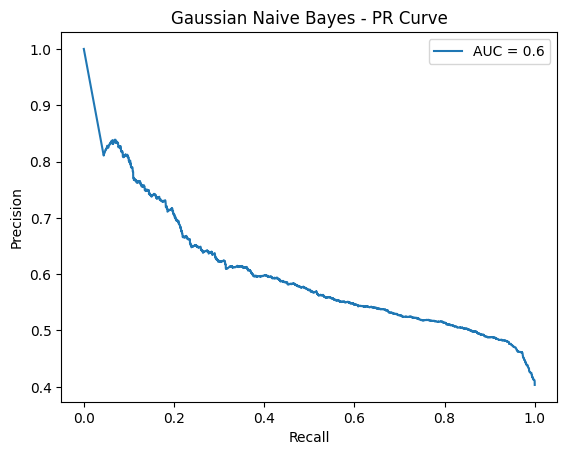

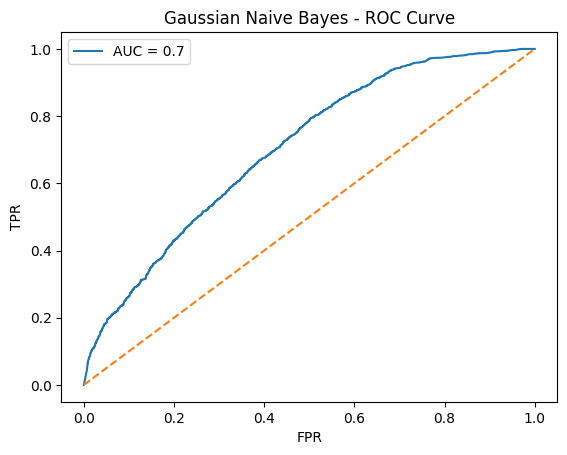

In [ ]:
y_score = model.predict_proba(X_test)[:, 1]
plot_pr_curve(y_test, y_score, title='Gaussian Naive Bayes - PR Curve')
plot_roc_curve(y_test, y_score, title='Gaussian Naive Bayes - ROC Curve')

#### Logistic Regression

In [ ]:
class LogisticRegression:
  def __init__(self, lr=0.01, epochs=1000, lambda_val=0.01, reg_type=None):
    self.lr = lr
    self.epochs = epochs
    self.lambda_val = lambda_val
    self.reg_type = reg_type
    self.W = None
    self.b = None
    self.losses = []
    self.accuracies = []
    self.val_losses = []
    self.val_accuracies = []

  def softmax(self, Z):
    Z_shifted = Z - np.max(Z, axis=1, keepdims=True)
    return np.exp(Z_shifted) / np.sum(np.exp(Z_shifted), axis=1, keepdims=True)

  def predict_proba(self, X):
    Z = X @ self.W + self.b
    return self.softmax(Z)

  def cross_entropy_loss(self, probs, y_one_hot):
    probs = np.clip(probs, 1e-15, 1.0)
    return -np.mean(np.sum(y_one_hot * np.log(probs), axis=1))

  def compute_gradient(self, X, y_one_hot, y_pred):
    num_samples = X.shape[0]
    grad_loss = X.T @ (y_pred - y_one_hot) / num_samples

    if self.reg_type == 'l2' and self.lambda_val > 0:
        grad_reg = (self.lambda_val / num_samples) * self.W
    elif self.reg_type == 'l1' and self.lambda_val > 0:
        grad_reg = (self.lambda_val / num_samples) * np.sign(self.W)
    else:
        grad_reg = 0

    return grad_loss + grad_reg

  def fit(self, X, y, X_val, y_val):
    num_classes = len(np.unique(y))
    num_samples, num_features = X.shape

    self.W = np.zeros((num_features, num_classes))
    self.b = np.zeros(num_classes)
    self.losses = []
    self.accuracies = []
    self.val_losses = []
    self.val_accuracies = []

    y_one_hot = np.zeros((len(y), num_classes))
    for i in range(len(y)):
      y_one_hot[i][y[i]] = 1

    y_one_hot_val = np.zeros((len(y_val), num_classes))
    for i in range(len(y_val)):
      y_one_hot_val[i][y_val[i]] = 1

    best_val_loss = float('inf')
    patience_count = 0

    for epoch in range(self.epochs):
      probs = self.predict_proba(X)
      y_pred = np.argmax(probs, axis=1)
      val_probs = self.predict_proba(X_val)
      val_pred = np.argmax(val_probs, axis=1)

      accuracy = np.mean(y_pred == y)
      self.accuracies.append(accuracy)
      val_accuracy = np.mean(val_pred == y_val)
      self.val_accuracies.append(val_accuracy)

      loss = self.cross_entropy_loss(probs, y_one_hot)
      val_loss = self.cross_entropy_loss(val_probs, y_one_hot_val)
      if self.reg_type == 'l2':
        l2_loss = (self.lambda_val / (2 * num_samples)) * np.sum(self.W**2)
        loss += l2_loss
        val_loss += l2_loss
      elif self.reg_type == 'l1':
        l1_loss = (self.lambda_val / num_samples) * np.sum(np.abs(self.W))
        loss += l1_loss
        val_loss += l1_loss
      self.losses.append(loss)
      self.val_losses.append(val_loss)

      if epoch % 50 == 0:
        print(f"Epoch {epoch}: loss = {loss:.4f}, accuracy: {accuracy:.4f}, val_loss = {val_loss:.4f}, val_accuracy: {val_accuracy:.4f}")

      if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_count = 0
      else:
        patience_count += 1

      if patience_count >= 50:
        print(f"Early stopping at epoch {epoch}")
        break

      dW = self.compute_gradient(X, y_one_hot, probs)
      db = np.mean(probs - y_one_hot, axis=0)
      self.W -= self.lr * dW
      self.b -= self.lr * db

  def predict(self, X):
    probs = self.predict_proba(X)
    return np.argmax(probs, axis=1)

Epoch 0: loss = 0.6931, accuracy: 0.5608, val_loss = 0.6931, val_accuracy: 0.5672
Epoch 50: loss = 0.5711, accuracy: 0.6940, val_loss = 0.5545, val_accuracy: 0.7139
Epoch 100: loss = 0.5665, accuracy: 0.6941, val_loss = 0.5522, val_accuracy: 0.7162
Epoch 150: loss = 0.5650, accuracy: 0.6938, val_loss = 0.5521, val_accuracy: 0.7187
Early stopping at epoch 179
Model Evaluation
----------------
Accuracy: 0.6402
Precision: 0.6261
Recall: 0.6260
Macro F1 Score: 0.6261
Weighted F1 Score: 0.6401
MSE: 0.3598

Confusion Matrix:
[[5730 2465]
 [2477 3063]]


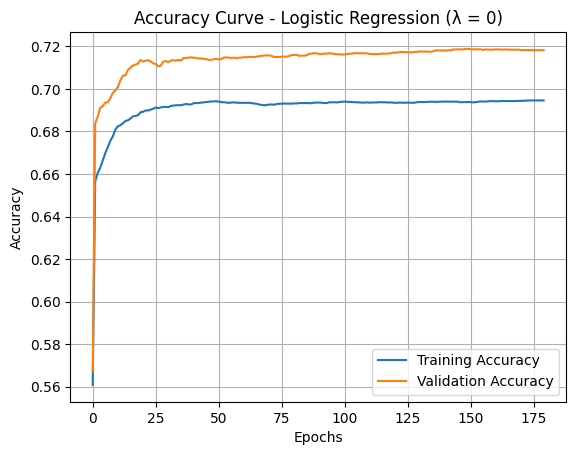

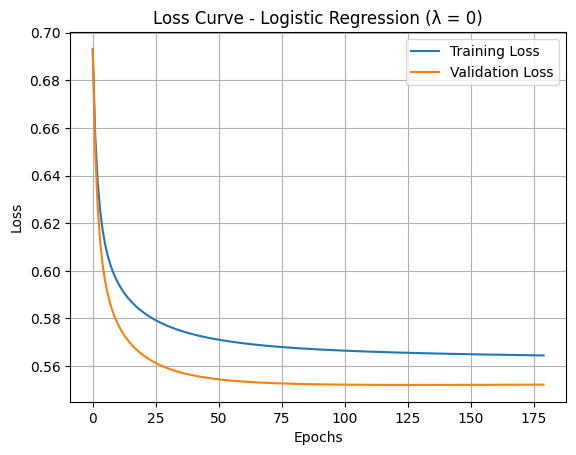

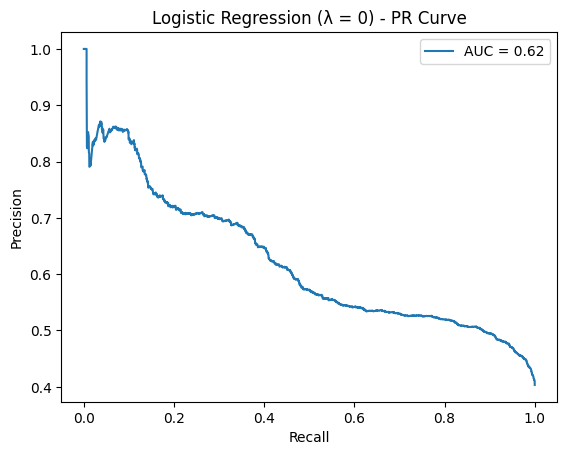

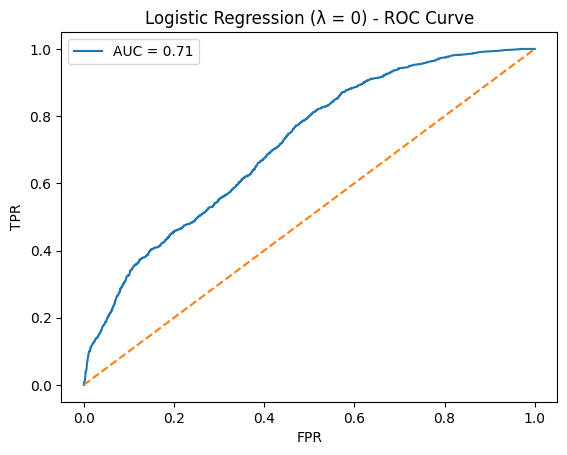

Epoch 0: loss = 0.6931, accuracy: 0.5608, val_loss = 0.6931, val_accuracy: 0.5672
Epoch 50: loss = 0.5711, accuracy: 0.6940, val_loss = 0.5545, val_accuracy: 0.7139
Epoch 100: loss = 0.5665, accuracy: 0.6941, val_loss = 0.5522, val_accuracy: 0.7162
Epoch 150: loss = 0.5650, accuracy: 0.6938, val_loss = 0.5521, val_accuracy: 0.7187
Early stopping at epoch 179
Model Evaluation
----------------
Accuracy: 0.6402
Precision: 0.6261
Recall: 0.6260
Macro F1 Score: 0.6261
Weighted F1 Score: 0.6401
MSE: 0.3598

Confusion Matrix:
[[5730 2465]
 [2477 3063]]


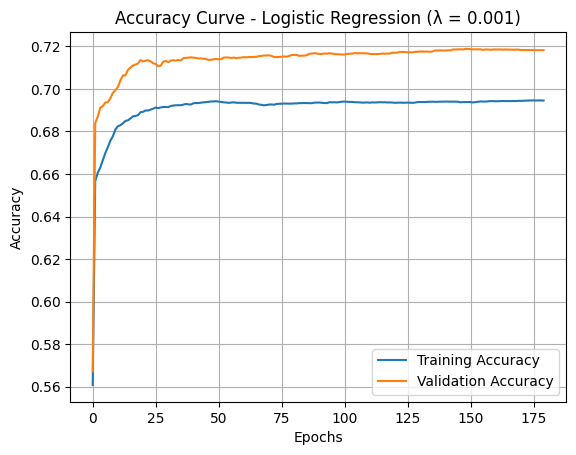

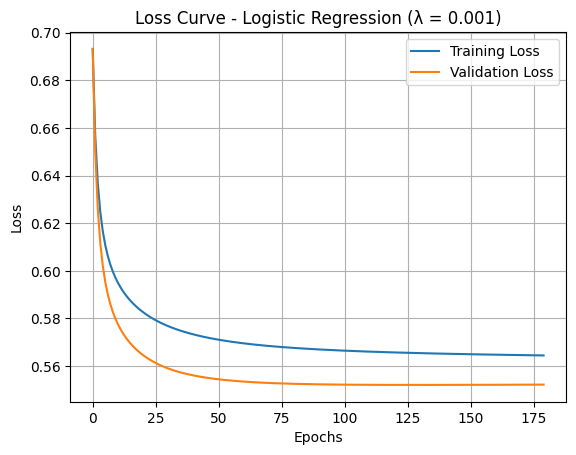

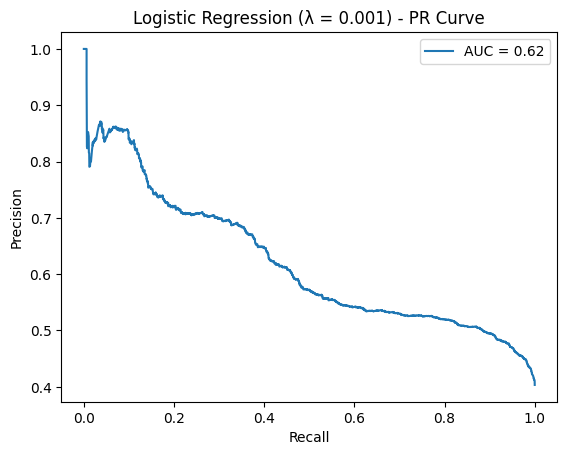

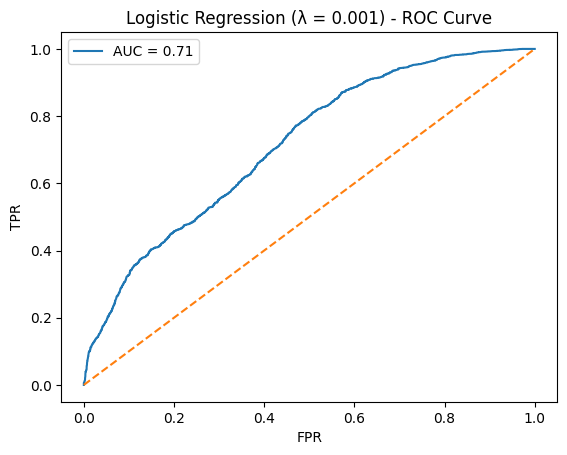

Epoch 0: loss = 0.6931, accuracy: 0.5608, val_loss = 0.6931, val_accuracy: 0.5672
Epoch 50: loss = 0.5711, accuracy: 0.6940, val_loss = 0.5545, val_accuracy: 0.7139
Epoch 100: loss = 0.5665, accuracy: 0.6941, val_loss = 0.5522, val_accuracy: 0.7162
Epoch 150: loss = 0.5650, accuracy: 0.6938, val_loss = 0.5521, val_accuracy: 0.7187
Early stopping at epoch 179
Model Evaluation
----------------
Accuracy: 0.6402
Precision: 0.6261
Recall: 0.6260
Macro F1 Score: 0.6261
Weighted F1 Score: 0.6401
MSE: 0.3598

Confusion Matrix:
[[5730 2465]
 [2477 3063]]


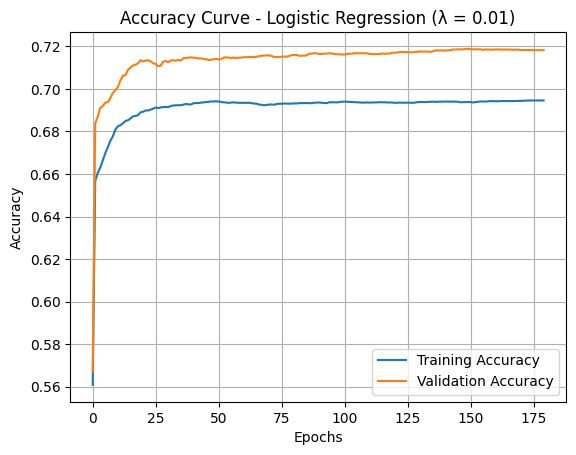

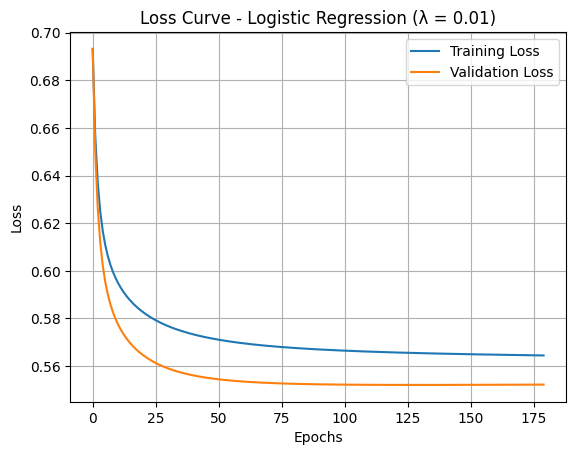

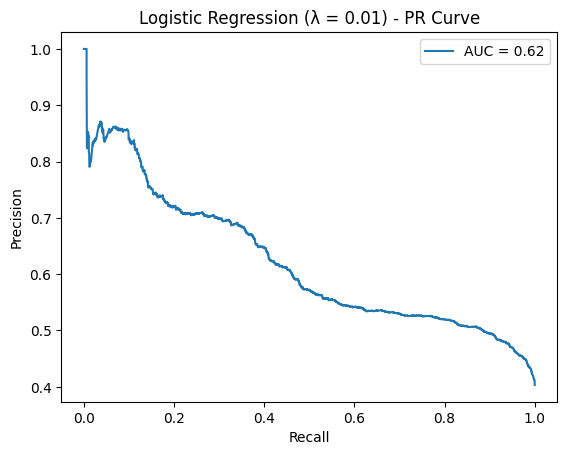

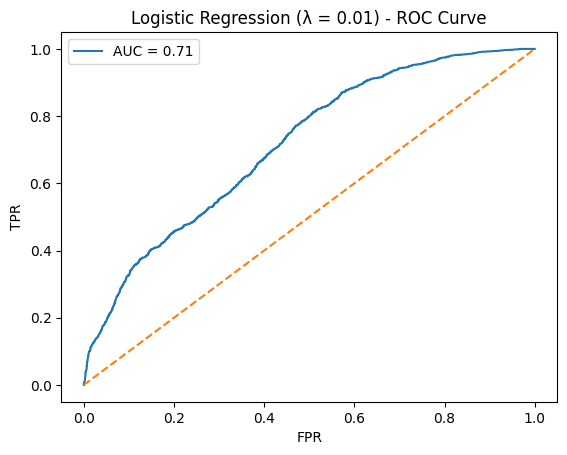

Epoch 0: loss = 0.6931, accuracy: 0.5608, val_loss = 0.6931, val_accuracy: 0.5672
Epoch 50: loss = 0.5711, accuracy: 0.6940, val_loss = 0.5545, val_accuracy: 0.7139
Epoch 100: loss = 0.5665, accuracy: 0.6941, val_loss = 0.5522, val_accuracy: 0.7162
Epoch 150: loss = 0.5650, accuracy: 0.6938, val_loss = 0.5521, val_accuracy: 0.7187
Early stopping at epoch 179
Model Evaluation
----------------
Accuracy: 0.6402
Precision: 0.6261
Recall: 0.6260
Macro F1 Score: 0.6261
Weighted F1 Score: 0.6401
MSE: 0.3598

Confusion Matrix:
[[5730 2465]
 [2477 3063]]


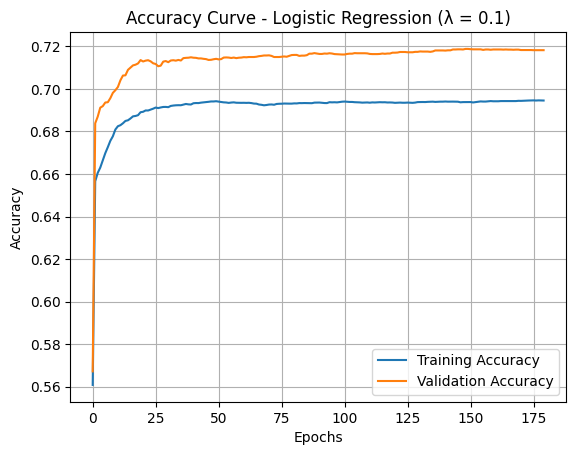

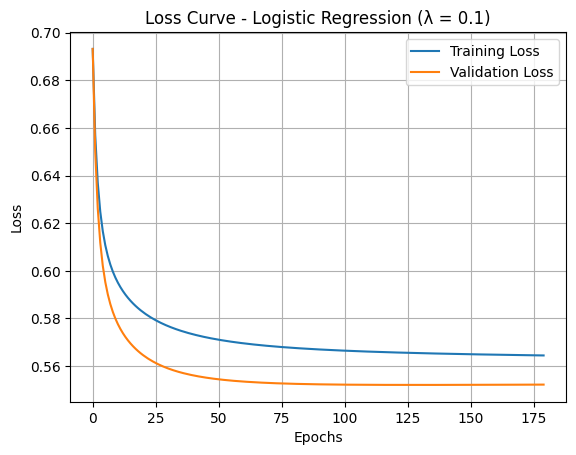

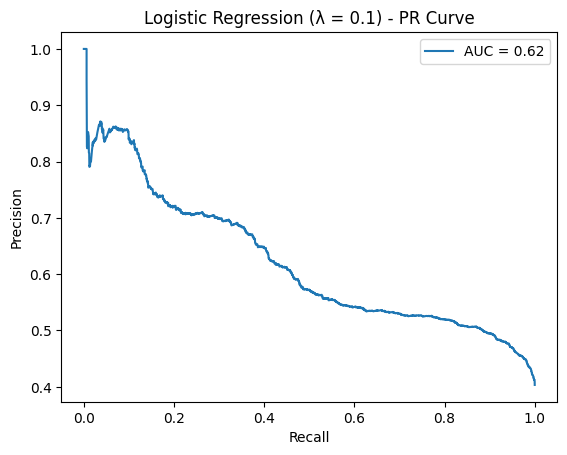

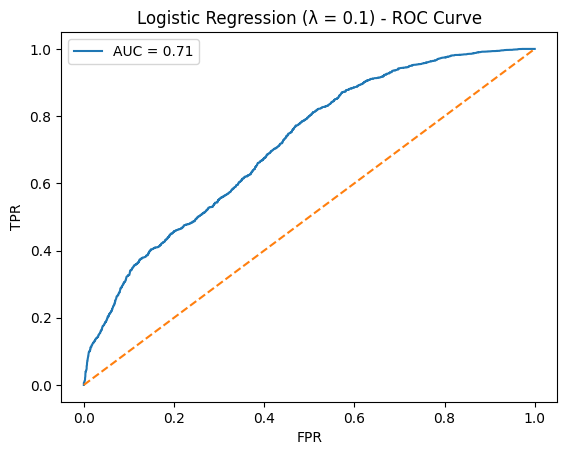

In [ ]:
lambda_vals = [0, 0.1, 1, 10]
for lambda_val in lambda_vals:
  model = LogisticRegression(
      lr=0.1,
      epochs=1000,
      lambda_val=lambda_val,
      reg_type='l2'
  )

  model.fit(X_train, y_train, X_val, y_val)

  y_pred = model.predict(X_test)
  metrics = evaluate_model(y_test, y_pred)
  print_metrics(metrics)

  plot_accuracy_curve(model.accuracies, model.val_accuracies, f"Logistic Regression (λ = {lambda_val})")
  plot_loss_curve(model.losses, model.val_losses, f"Logistic Regression (λ = {lambda_val})")
  y_score = model.predict_proba(X_test)[:, 1]
  plot_pr_curve(y_test, y_score, title=f"Logistic Regression (λ = {lambda_val}) - PR Curve")
  plot_roc_curve(y_test, y_score, title=f"Logistic Regression (λ = {lambda_val}) - ROC Curve")

K Nearest Neighbors

In [11]:

class KNN:
  def __init__(self, k):
    self.k = k
    self.X_train = None
    self.y_train = None

  def fit(self, X, y):
    #float 32 to preserve memory so google colab doesnt insta crash
    self.X_train = X.astype(np.float32)
    self.y_train = y.astype(np.float32)


  def euclidean_distance(self, X):
    sq_test = np.sum(X ** 2, axis=1, keepdims=True)
    sq_train = np.sum(self.X_train ** 2, axis=1, keepdims=True).T
    cross_term = X @ self.X_train.T
    dist_sq  = sq_test + sq_train - 2 * cross_term
    return np.sqrt(np.maximum(dist_sq, 0.0))

  def predict(self, X, chunk_size=500):
    X = X.astype(np.float32)
    n_test = X.shape[0]
    predictions = []

    for start in range(0, n_test, chunk_size):
        X_chunk = X[start:start + chunk_size]          # (chunk, features)

        # Only (chunk × n_train) in memory at once — ~500MB max at chunk=500
        #batches to not crash google colab instantly
        sq_test  = np.sum(X_chunk ** 2, axis=1, keepdims=True)
        sq_train = np.sum(self.X_train ** 2, axis=1, keepdims=True).T
        cross    = X_chunk @ self.X_train.T
        dist     = np.sqrt(np.maximum(sq_test + sq_train - 2 * cross, 0.0))

        knn_idx    = np.argpartition(dist, self.k, axis=1)[:, :self.k]
        knn_labels = self.y_train[knn_idx]

        classes = np.unique(self.y_train)
        for labels in knn_labels:
            counts = np.array([np.sum(labels == c) for c in classes])
            predictions.append(classes[np.argmax(counts)])

    return np.array(predictions)

  def predict_proba(self, X, chunk_size=500):
    X = X.astype(np.float32)
    n_test = X.shape[0]
    proba = []

    for start in range(0, n_test, chunk_size):
        X_chunk = X[start:start + chunk_size]
        sq_test  = np.sum(X_chunk ** 2, axis=1, keepdims=True)
        sq_train = np.sum(self.X_train ** 2, axis=1, keepdims=True).T
        cross    = X_chunk @ self.X_train.T
        dist     = np.sqrt(np.maximum(sq_test + sq_train - 2 * cross, 0.0))

        knn_idx    = np.argpartition(dist, self.k, axis=1)[:, :self.k]
        knn_labels = self.y_train[knn_idx]

        for labels in knn_labels:
            prob_pos = np.mean(labels == 1)  # fraction of neighbors that are class 1
            proba.append(prob_pos)

    return np.array(proba)


In [12]:
k_values = [1, 5, 10, 15, 30]

best_knn       = None
best_knn_acc   = float('-inf')
best_k         = None

for k in k_values:
    model   = KNN(k=k)
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)
    val_acc    = np.mean(y_val_pred == y_val)
    print(f"k={k:2d}  val_accuracy={val_acc:.4f}")
    if val_acc > best_knn_acc:
        best_knn_acc = val_acc
        best_knn     = model
        best_k       = k

print(f"\nBest k={best_k}  (val_accuracy={best_knn_acc:.4f})")
print("\n--- Test set evaluation ---")
y_pred   = best_knn.predict(X_test)
metrics  = evaluate_model(y_test, y_pred)
print_metrics(metrics)

k= 1  val_accuracy=0.6496
k= 5  val_accuracy=0.6683
k=10  val_accuracy=0.6838
k=15  val_accuracy=0.6860
k=30  val_accuracy=0.6992

Best k=30  (val_accuracy=0.6992)

--- Test set evaluation ---
Model Evaluation
----------------
Accuracy: 0.6809
Precision: 0.6677
Recall: 0.6656
Macro F1 Score: 0.6665
Weighted F1 Score: 0.6799
MSE: 0.3191

Confusion Matrix:
[[6102 2093]
 [2290 3250]]


### Advanced Models

#### Decision Trees

In [ ]:
class Node:
  def __init__(self, feat_idx, threshold, left, right, value):
    self.feat_idx = feat_idx
    self.threshold = threshold
    self.left = left
    self.right = right
    self.value = value
    self.is_leaf = False

class LeafNode:
  def __init__(self, label, probs):
    self.label = label
    self.probs = probs
    self.is_leaf = True

class DecisionTree:
  def __init__(self, max_depth=10, min_split=2):
    self.max_depth = max_depth
    self.min_split = min_split
    self.root = None

  def compute_gini(self, y):
    classes = np.unique(y)
    probs = []
    for c in classes:
      probs.append(np.sum(y == c) / len(y))
    probs = np.array(probs)
    return 1 - np.sum(probs ** 2)

  def build_tree(self, X, y, depth):
    if (depth >= self.max_depth or self.min_split > len(y) or len(np.unique(y)) == 1):
      class_labels, class_counts = np.unique(y, return_counts=True)
      pred_class = class_labels[np.argmax(class_counts)]
      probs = np.zeros(len(self.classes))
      for i, c in enumerate(self.classes):
        probs[i] = np.sum(y == c) / len(y)
      return LeafNode(pred_class, probs)

    num_samples, num_features = X.shape
    split_feature = None
    split_threshold = None
    min_score = float('inf')

    for feat_idx in range(num_features):
      X_feat = X[:, feat_idx]
      possible_thresholds = np.sort(np.unique(X_feat))
      thresholds = (possible_thresholds[:-1] + possible_thresholds[1:]) / 2
      for t in thresholds:
        left_idx = X_feat <= t
        right_idx = X_feat > t

        y_left = y[left_idx]
        y_right = y[right_idx]

        if len(y_left) == 0 or len(y_right) == 0:
          continue

        left_gini = self.compute_gini(y_left)
        right_gini = self.compute_gini(y_right)

        weighted_gini = (len(y_left) / num_samples) * left_gini + (len(y_right) / num_samples) * right_gini

        if weighted_gini < min_score:
          split_feature = feat_idx
          split_threshold = t
          min_score = weighted_gini

    if split_feature is None:
      class_labels, class_counts = np.unique(y, return_counts=True)
      pred_class = class_labels[np.argmax(class_counts)]
      probs = np.zeros(len(self.classes))
      for i, c in enumerate(self.classes):
        probs[i] = np.sum(y == c) / len(y)
      return LeafNode(pred_class, probs)

    left_idx = X[:, split_feature] <= split_threshold
    right_idx = X[:, split_feature] > split_threshold

    X_left, X_right = X[left_idx], X[right_idx]
    y_left, y_right = y[left_idx], y[right_idx]

    left_node = self.build_tree(X_left, y_left, depth + 1)
    right_node = self.build_tree(X_right, y_right, depth + 1)

    return Node(split_feature, split_threshold, left_node, right_node, min_score)

  def fit(self, X, y):
    self.classes = np.unique(y)
    self.root = self.build_tree(X, y, depth=0)

  def predict_sample(self, X, node):
    if node.is_leaf:
      return node.label

    if X[node.feat_idx] <= node.threshold:
      return self.predict_sample(X, node.left)
    else:
      return self.predict_sample(X, node.right)

  def predict(self, X):
    predictions = []
    for sample in X:
      predictions.append(self.predict_sample(sample, self.root))
    return np.array(predictions)

  def predict_proba_sample(self, X, node):
    if node.is_leaf:
      return node.probs

    if X[node.feat_idx] <= node.threshold:
      return self.predict_proba_sample(X, node.left)
    else:
      return self.predict_proba_sample(X, node.right)

  def predict_probs(self, X):
    probs = []
    for sample in X:
      probs.append(self.predict_proba_sample(sample, self.root))
    return np.array(probs)

In [ ]:
max_depth = [3, 5, 10, 15]
min_split = [2, 5, 10, 20]

best_model = None
best_accuracy = float('-inf')
best_depth = None
best_split = None

for depth in max_depth:
  for split in min_split:
    model = DecisionTree(max_depth=depth, min_split=split)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    metrics = evaluate_model(y_test, y_pred)
    if metrics['accuracy'] > best_accuracy:
      best_accuracy = metrics['accuracy']
      best_model = model
      best_depth = depth
      best_split = split
print(best_model)
print(best_depth)
print(best_split)

In [ ]:
y_pred = best_model.predict(X_test)
metrics = evaluate_model(y_test, y_pred)
print_metrics(metrics)
y_score = model.predict_proba(X_test)[:, 1]
plot_pr_curve(y_test, y_score, title='Decision Tree - PR Curve')
plot_roc_curve(y_test, y_score, title='Decision Tree - ROC Curve')

TypeError: '>=' not supported between instances of 'int' and 'NoneType'

SVM (adv model 2)

In [13]:
class LinearSVM:

    def __init__(self, lr=1e-3, lambda_reg=1e-2, epochs=1000, batch_size=256):
        self.lr          = lr
        self.lambda_reg  = lambda_reg
        self.epochs      = epochs
        self.batch_size  = batch_size
        self.W           = None
        self.b           = None
        self.train_losses = []
        self.val_losses   = []
        self.train_accs   = []
        self.val_accs     = []

    @staticmethod
    def _to_bipolar(y):
        return np.where(y == 1, 1, -1).astype(float)

    def _hinge_loss(self, X, y_bip):
        margins = y_bip * (X @ self.W + self.b)           # (n,)
        hinge   = np.maximum(0.0, 1.0 - margins)
        reg     = 0.5 * self.lambda_reg * np.dot(self.W, self.W)
        return reg + np.mean(hinge)

    def _accuracy(self, X, y_orig):
        return np.mean(self.predict(X) == y_orig)

    def fit(self, X, y, X_val, y_val):
        n_samples, n_features = X.shape
        self.W = np.zeros(n_features)
        self.b = 0.0

        y_bip     = self._to_bipolar(y)
        y_val_bip = self._to_bipolar(y_val)

        for epoch in range(self.epochs):
            idx = np.random.permutation(n_samples)
            X_s, y_s = X[idx], y_bip[idx]

            # Mini-batch SGD
            for start in range(0, n_samples, self.batch_size):
                Xb = X_s[start:start + self.batch_size]
                yb = y_s[start:start + self.batch_size]
                nb = len(yb)

                margins = yb * (Xb @ self.W + self.b)
                threshold = margins < 1

                # Gradient of W
                dW = self.lambda_reg * self.W
                if threshold.any():
                    dW -= (1.0 / nb) * (yb[threshold, None] * Xb[threshold]).sum(axis=0)

                # Gradient of b
                db = 0.0
                if threshold.any():
                    db = -(1.0 / nb) * yb[threshold].sum()

                self.W -= self.lr * dW
                self.b -= self.lr * db

            tr_loss = self._hinge_loss(X, y_bip)
            vl_loss = self._hinge_loss(X_val, y_val_bip)
            tr_acc  = self._accuracy(X, y)
            vl_acc  = self._accuracy(X_val, y_val)

            self.train_losses.append(tr_loss)
            self.val_losses.append(vl_loss)
            self.train_accs.append(tr_acc)
            self.val_accs.append(vl_acc)

            if epoch % 100 == 0 or epoch == self.epochs - 1:
                print(f"Epoch {epoch:3d}: "
                      f"train_loss={tr_loss:.4f}  val_loss={vl_loss:.4f}  "
                      f"train_acc={tr_acc:.4f}  val_acc={vl_acc:.4f}")

    def predict(self, X):
        scores = X @ self.W + self.b
        return (scores >= 0).astype(int)

    def decision_function(self, X):
        return X @ self.W + self.b

Epoch   0: train_loss=0.7153  val_loss=0.6877  train_acc=0.6856  val_acc=0.6982
Epoch 100: train_loss=0.6848  val_loss=0.6588  train_acc=0.6956  val_acc=0.7123
Epoch 200: train_loss=0.6848  val_loss=0.6593  train_acc=0.6953  val_acc=0.7114
Epoch 300: train_loss=0.6850  val_loss=0.6563  train_acc=0.6960  val_acc=0.7141
Epoch 400: train_loss=0.6849  val_loss=0.6594  train_acc=0.6962  val_acc=0.7114
Epoch 500: train_loss=0.6848  val_loss=0.6590  train_acc=0.6959  val_acc=0.7123
Epoch 600: train_loss=0.6849  val_loss=0.6578  train_acc=0.6958  val_acc=0.7128
Epoch 700: train_loss=0.6851  val_loss=0.6567  train_acc=0.6958  val_acc=0.7142
Epoch 800: train_loss=0.6849  val_loss=0.6600  train_acc=0.6963  val_acc=0.7119
Epoch 900: train_loss=0.6848  val_loss=0.6590  train_acc=0.6956  val_acc=0.7127
Epoch 999: train_loss=0.6849  val_loss=0.6584  train_acc=0.6959  val_acc=0.7131
lr=0.01  lambda=0.01  => val_acc=0.7131

Epoch   0: train_loss=0.7145  val_loss=0.6862  train_acc=0.6858  val_acc=0.7001

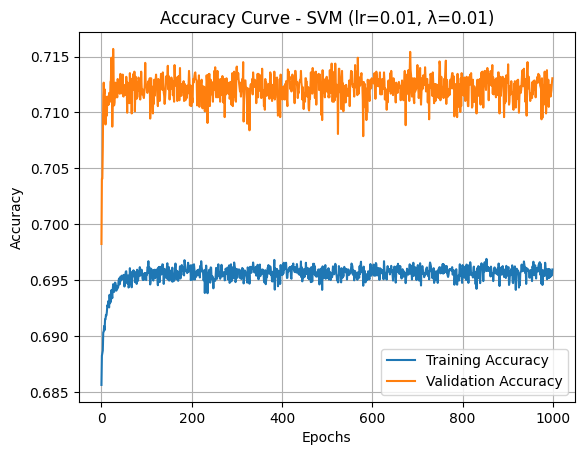

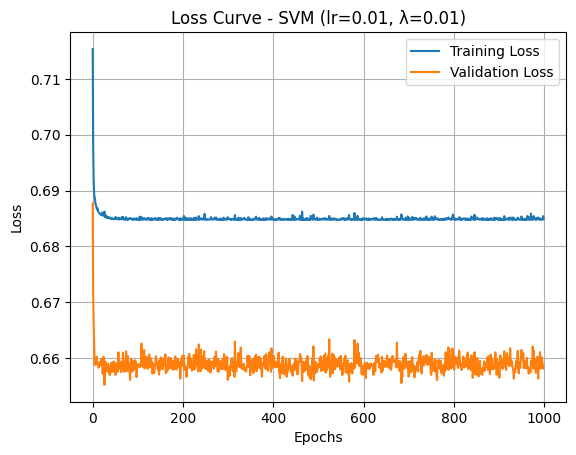

In [16]:

# Grid search over C = 1/lambda and learning rate
lr_values     = [1e-2, 1e-3]
lambda_values = [1e-2, 1e-3, 1e-4]

best_svm     = None
best_svm_acc = float('-inf')
best_params  = {}

for lr in lr_values:
    for lam in lambda_values:
        model = LinearSVM(lr=lr, lambda_reg=lam, epochs=1000, batch_size=256)
        model.fit(X_train, y_train, X_val, y_val)
        val_acc = np.mean(model.predict(X_val) == y_val)
        print(f"lr={lr}  lambda={lam}  => val_acc={val_acc:.4f}\n")
        if val_acc > best_svm_acc:
            best_svm_acc = val_acc
            best_svm     = model
            best_params  = {"lr": lr, "lambda_reg": lam}

print(f"\nBest params: {best_params}  (val_accuracy={best_svm_acc:.4f})")
print("\n--- Test set evaluation ---")
y_pred  = best_svm.predict(X_test)
metrics = evaluate_model(y_test, y_pred)
print_metrics(metrics)

plot_accuracy_curve(best_svm.train_accs, best_svm.val_accs,
                    f"SVM (lr={best_params['lr']}, λ={best_params['lambda_reg']})")
plot_loss_curve(best_svm.train_losses, best_svm.val_losses,
                f"SVM (lr={best_params['lr']}, λ={best_params['lambda_reg']})")


In [ ]:
# Plot ROC curve for SVM
y_score_svm = best_svm.decision_function(X_test)
plot_roc_curve(y_test, y_score_svm, title=f"SVM (lr={best_params['lr']}, λ={best_params['lambda_reg']}) - ROC Curve")

Random Forest (Black Box Implementation)

In [18]:
from sklearn.ensemble import RandomForestClassifier

n_est_values = [25, 50, 100]
depth_values = [5, 10, 15]

best_rf      = None
best_rf_acc  = float('-inf')
best_rf_params = {}

for n_est in n_est_values:
    for depth in depth_values:
        model = RandomForestClassifier(
            n_estimators=n_est,
            max_depth=depth,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train, y_train)
        val_acc = np.mean(model.predict(X_val) == y_val)
        print(f"n_estimators={n_est:3d}  max_depth={depth:2d}  => val_acc={val_acc:.4f}")

        if val_acc > best_rf_acc:
            best_rf_acc    = val_acc
            best_rf        = model
            best_rf_params = {"n_estimators": n_est, "max_depth": depth}

print(f"\nBest RF params: {best_rf_params}  (val_accuracy={best_rf_acc:.4f})")
print("\n--- Test set evaluation ---")
y_pred  = best_rf.predict(X_test)
metrics = evaluate_model(y_test, y_pred)
print_metrics(metrics)

n_estimators= 25  max_depth= 5  => val_acc=0.7178
n_estimators= 25  max_depth=10  => val_acc=0.7390
n_estimators= 25  max_depth=15  => val_acc=0.7421
n_estimators= 50  max_depth= 5  => val_acc=0.7207
n_estimators= 50  max_depth=10  => val_acc=0.7399
n_estimators= 50  max_depth=15  => val_acc=0.7435
n_estimators=100  max_depth= 5  => val_acc=0.7196
n_estimators=100  max_depth=10  => val_acc=0.7359
n_estimators=100  max_depth=15  => val_acc=0.7457

Best RF params: {'n_estimators': 100, 'max_depth': 15}  (val_accuracy=0.7457)

--- Test set evaluation ---
Model Evaluation
----------------
Accuracy: 0.7008
Precision: 0.6891
Recall: 0.6887
Macro F1 Score: 0.6889
Weighted F1 Score: 0.7007
MSE: 0.2992

Confusion Matrix:
[[6158 2037]
 [2072 3468]]


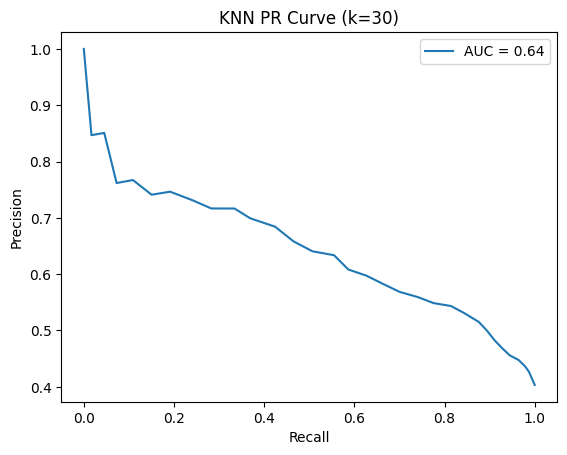

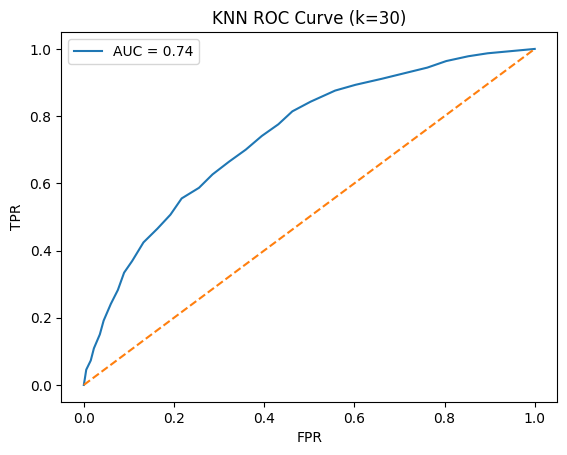

In [15]:
# KNN
y_score_knn = best_knn.predict_proba(X_test)
plot_pr_curve(y_test, y_score_knn, title=f'KNN PR Curve (k={best_k})')
plot_roc_curve(y_test, y_score_knn, title=f'KNN ROC Curve (k={best_k})')



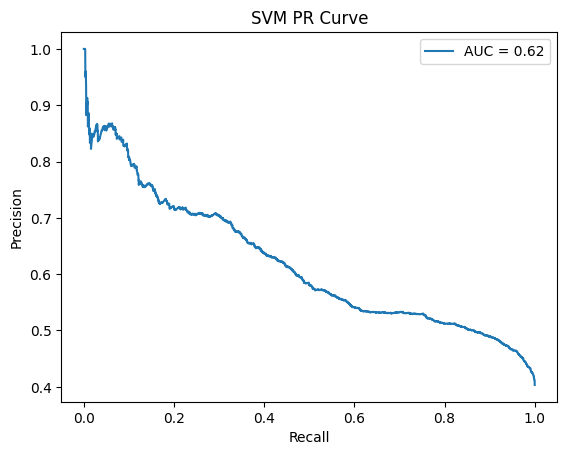

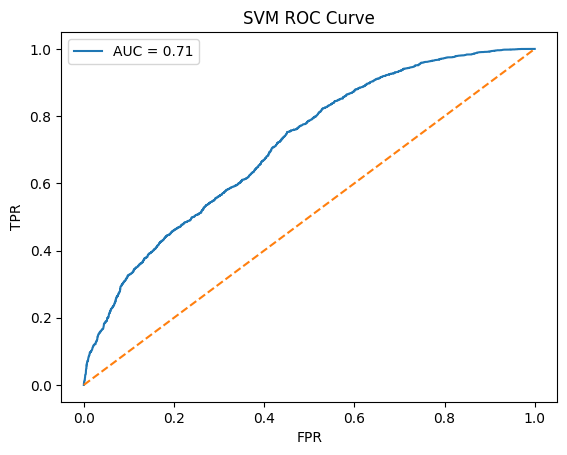

In [17]:
# SVM
y_score_svm = best_svm.decision_function(X_test)
plot_pr_curve(y_test, y_score_svm, title=f'SVM PR Curve')
plot_roc_curve(y_test, y_score_svm, title=f'SVM ROC Curve')



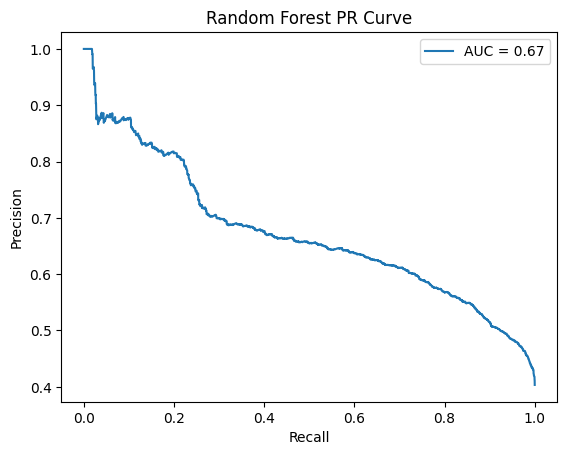

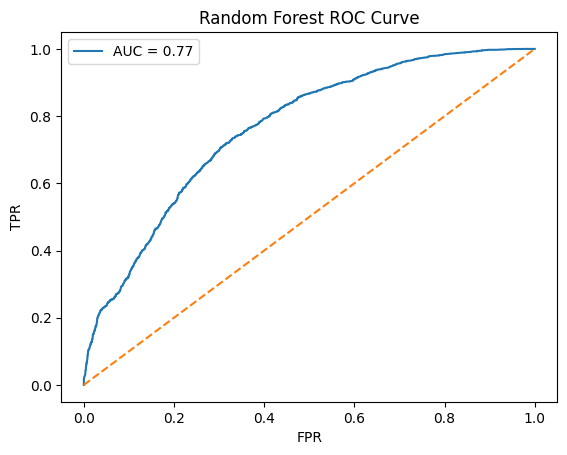

In [19]:
# Random Forest
y_score_rf = best_rf.predict_proba(X_test)[:, 1]
plot_pr_curve(y_test, y_score_rf, title='Random Forest PR Curve')
plot_roc_curve(y_test, y_score_rf, title='Random Forest ROC Curve')